<a href="https://colab.research.google.com/github/richardparik/Projects/blob/master/FINAL%20project/Final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brain Tumor

Dataset k projektu
https://www.kaggle.com/datasets/denizkavi1/brain-tumor?resource=download

1. 1 Meningioma samples (708 files) = tumor that grows from the membranes that surround the brain and spinal cord,
v naprosté většině případů nezhoubný nádor, který vyrůstá z obalu mozku takzvané tvrdé pleny
2. 2 Glioma samples (1426 files) =a growth of cells that starts in the brain or spinal cord,
typ tumoru, jenž vzniká v mozku nebo míše
3. 3 Pituitary tumor samples (930 files) =tumors that occur in the pituitary gland. Most pituitary tumors are benign, approximately 35% are invasive and just 0.1% to 0.2% are carcinomas



Below is a revised version of your notebook code that incorporates many of the recommended best practices and a clearer overall structure. The key improvements include:

1.Consistent Data Splitting: Creating a train/validation/test split.
2.Data Augmentation: Using ImageDataGenerator (or tf.data pipelines) to augment images and help combat overfitting.
3. Transfer Learning: Demonstrating a transfer learning pipeline using MobileNetV2 (as your original code did).
Callbacks: Adding callbacks such as EarlyStopping and ModelCheckpoint.
Better Organization: Grouping code cells by logic—data exploration, data prep, model building, training, and evaluation.

In [104]:
pip install keras-tuner

In [105]:
############################
# 1. IMPORTS & SETUP
############################
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                     Dropout, BatchNormalization, GlobalAveragePooling2D)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.applications import VGG16, MobileNetV2
import kagglehub
import keras_tuner as kt
import keras
from sklearn.metrics import confusion_matrix, classification_report


# Step 1: Dataset Exploration
Download the dataset from Kaggle.
Explore the dataset structure (number of classes, sample images, etc.).
Check for data imbalances and preprocessing needs.


In [ ]:
# Download latest version
dataset_path = kagglehub.dataset_download("denizkavi1/brain-tumor")
label_map = {
    '1': 'Meningioma',
    '2': 'Glioma',
    '3': 'Pituitary'
}

print("Path to dataset files:", dataset_path)

Path to dataset files: /root/.cache/kagglehub/datasets/denizkavi1/brain-tumor/versions/2


## Count Images Per Category

In [ ]:
# Quick check: how many images per category?
for category in sorted(os.listdir(dataset_path)):
    category_path = os.path.join(dataset_path, category)
    if os.path.isdir(category_path):
        print(f"{label_map.get(category, category)}: {len(os.listdir(category_path))} images")

Meningioma: 708 images
Glioma: 1426 images
Pituitary: 930 images


## Display Sample Images

In [ ]:
def show_sample_images(root_path, num_samples=5):
    """
    Displays a few sample images from each class in grayscale or color as needed.
    """
    categories = sorted(os.listdir(root_path))
    # Filter out files vs. directories if needed:
    categories = [cat for cat in categories if os.path.isdir(os.path.join(root_path, cat))]

    fig, axes = plt.subplots(len(categories), num_samples, figsize=(15, 10))
    for i, category in enumerate(categories):
        category_path = os.path.join(root_path, category)
        images = random.sample(os.listdir(category_path), num_samples)

        for j, img_name in enumerate(images):
            img_path = os.path.join(category_path, img_name)
            # For MobileNetV2, we generally want 3-channel images
            # We'll read it in color:
            img = cv2.imread(img_path, cv2.IMREAD_COLOR)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (224, 224))  # just for display
            axes[i, j].imshow(img)
            axes[i, j].axis("off")
            if j == 0:
                axes[i, j].set_title(f"{label_map.get(category, category)}")

    plt.tight_layout()
    plt.show()

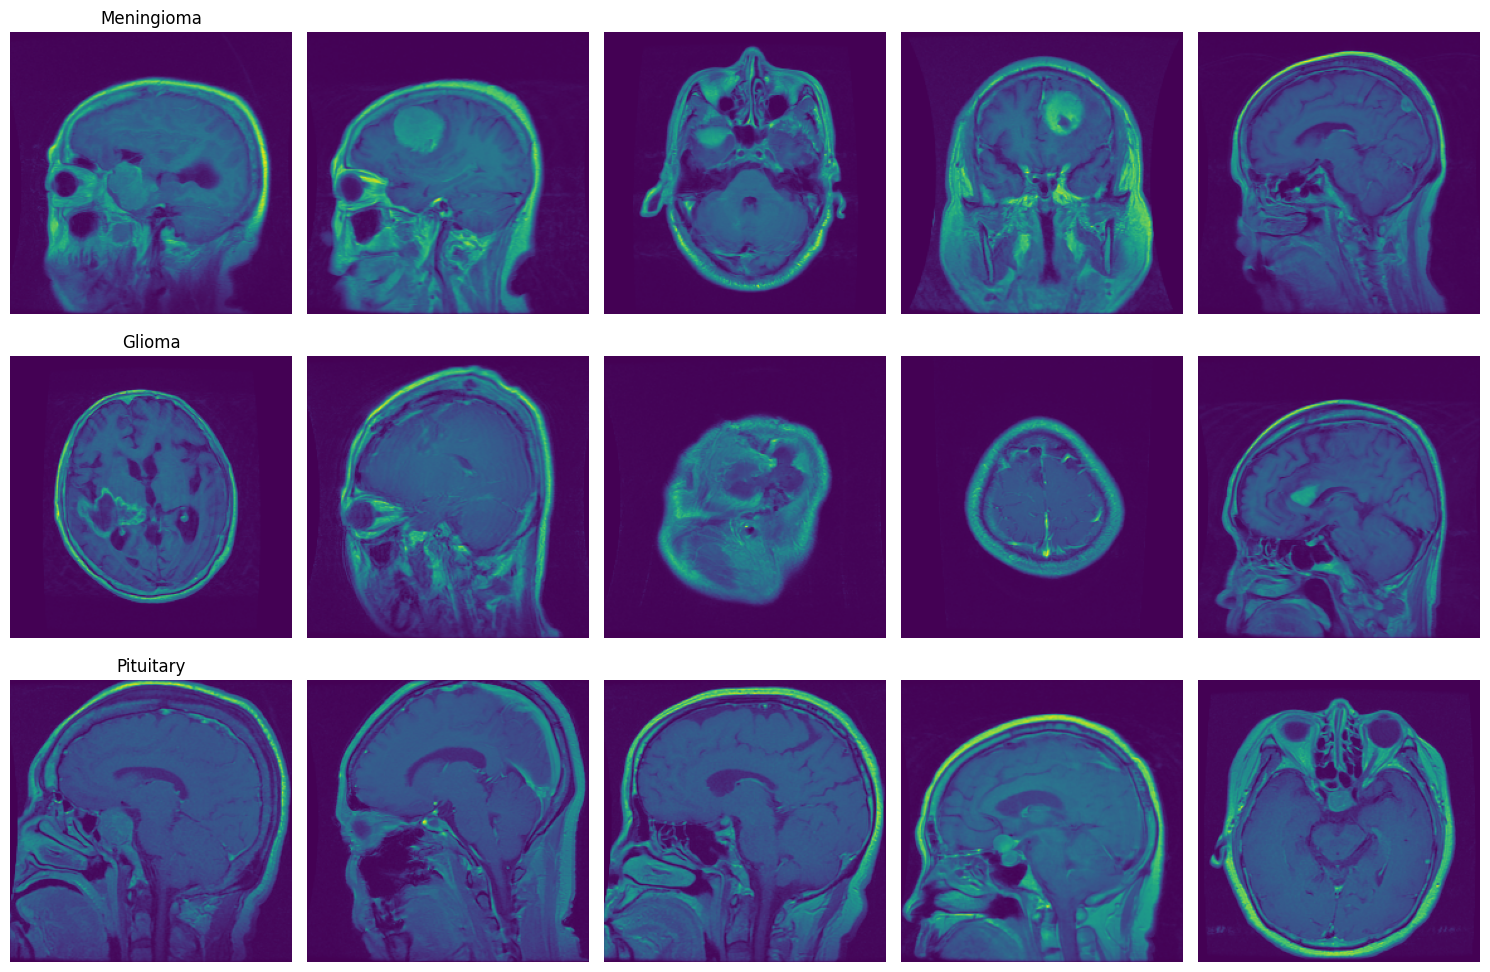

In [ ]:
# Display a few sample images
show_sample_images(dataset_path, num_samples=5)

# Step 2: train-val-test split

✅ Creates the main dataset folder (brain_tumor_split).
✅ Creates three subdirectories (train/, val/, test/).
✅ Creates category folders inside each split.

In [ ]:
# automatically creates a new directory structure to split your dataset into train, validation, and test sets (70/15/15 ratio).
import shutil #used for moving/copying files to different folders.
import pathlib #useful for working with paths in a system-independent way.

# We'll create a new folder 'brain_tumor_split' to hold the splitted subfolders
base_split_dir = 'brain_tumor_split' #main directory where all split data will be stored.
if not os.path.exists(base_split_dir):
    os.makedirs(base_split_dir) #Creates this folder if it doesn't exist already.

for split in ['train', 'val', 'test']: #Loops through ['train', 'val', 'test'] to create three subfolders inside brain_tumor_split/.
    split_dir = os.path.join(base_split_dir, split)
    if not os.path.exists(split_dir):
        os.makedirs(split_dir)
        # also create subdirs for each class
        for cat_key in label_map.keys():
            os.makedirs(os.path.join(split_dir, cat_key))


In [ ]:
"""
brain_tumor_split/
    ├── train/
    │   ├── 1/  (Meningioma images)
    │   ├── 2/  (Glioma images)
    │   ├── 3/  (Pituitary images)
    │
    ├── val/
    │   ├── 1/
    │   ├── 2/
    │   ├── 3/
    │
    ├── test/
        ├── 1/
        ├── 2/
        ├── 3/
"""

This function splits images into training, validation, and test sets using a 70/15/15 ratio (or any custom ratio). It then copies images into their respective folders.

In [ ]:
# Function to split the images
def split_data(original_dir, split_dir, split_ratio=(0.7, 0.15, 0.15)):
#folder containing images of one tumor class
#base folder where train, val, and test directories exist
#The percentage of data split (default = 70% train, 15% val, 15% test).
    """
    split_ratio: (train, val, test)
    """
    images = os.listdir(original_dir)
    images = [img for img in images if img.lower().endswith(('.png', '.jpg', '.jpeg'))] #Filters out only valid image files (.png, .jpg, .jpeg).
    random.shuffle(images) #Shuffles the list of images to ensure a random distribution.

    # Computes how many images go into train/val/test folders based on the ratio.
    n_total = len(images)
    n_train = int(split_ratio[0] * n_total)  # 70% for training
    n_val   = int(split_ratio[1] * n_total)  # 15% for validation
    n_test  = n_total - n_train - n_val  # Remaining 15% for testing

    train_files = images[:n_train] #training set
    val_files   = images[n_train:n_train+n_val] # validation set
    test_files  = images[n_train+n_val:] # test set

    # Copy files into the respective folders ("brain_tumor_split/train/{category}/" etc.)
    # shutil.copy() ensures that the original dataset is untouched, and a copy is placed in the correct split folder.
    for f in train_files:
        shutil.copy(os.path.join(original_dir, f),
                    os.path.join(split_dir, 'train', os.path.basename(original_dir), f))
    for f in val_files:
        shutil.copy(os.path.join(original_dir, f),
                    os.path.join(split_dir, 'val', os.path.basename(original_dir), f))
    for f in test_files:
        shutil.copy(os.path.join(original_dir, f),
                    os.path.join(split_dir, 'test', os.path.basename(original_dir), f))

# Apply split to each category folder, Loops through each class category (1, 2, 3).
for category in label_map.keys():
    cat_folder = os.path.join(dataset_path, category)
    if os.path.isdir(cat_folder):
        split_data(cat_folder, base_split_dir) # for each category to distribute images correctly.


# Step 3: Data augmentation

Tip1: Pohrát si s augmentation (rotování? atd?), Use data augmentation to introduce variations during training.
Tip2: If you want to push accuracy higher, try:

* Fine-tuning MobileNetV2 layers.
* Training for more epochs.
* Increasing dropout or adding L2 regularization.
* Checking for class imbalance in test data.

tip3: Test Loss (0.3001) is Higher than Validation Loss (0.2498)
* Increase dropout (e.g., Dropout(0.4) instead of Dropout(0.3)).
* Try adding L2 weight decay regularization in your dense layer
* Check class distribution in your test set to make sure it's balanced.

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,#rescales images automatically based on the pretrained model you are using, is a built-in function from TensorFlow/Keras applications.
    rotation_range=15, # Randomly rotates the image by up to ±15 degrees.
    width_shift_range=0.1, #Moves images left/right by up to 10% of the width.
    height_shift_range=0.1, #Moves images up/down by up to 10% of the height.
    horizontal_flip=True, #Flips images horizontally (left-right).
    fill_mode='nearest' #Fills missing pixels with nearest pixel values (best for medical images).
)
#The validation set is used to monitor performance during training.
#The test set is used after training to check final accuracy.
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input) #No augmentation for validation & test sets.,Only applies preprocess_input (normalization).
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_dir = os.path.join(base_split_dir, 'train') #Defines paths to training, validation, and test datasets.
val_dir   = os.path.join(base_split_dir, 'val') #These folders contain MRI images sorted by class (from previous splitting steps).
test_dir  = os.path.join(base_split_dir, 'test')

In [ ]:
batch_size = 32 #Images are grouped in chunks (batch_size=32), which is how the model receives data during training or inference.
img_size = (224, 224)

#creating three data generators.
#Each generator loads images from a directory structure on disk, resizes them, applies any specified preprocessing/augmentation
# and yields them in batches—ready to be fed into a model for training or evaluation.
train_generator = train_datagen.flow_from_directory(
    directory=train_dir, #Keras automatically recognizes each folder under train_dir as a class and assigns it a label (0 for ClassA, 1 for ClassB, etc.) in alphabetical order by default.
    target_size=img_size, #Each image loaded from disk is resized (or reshaped) to 224×224 pixels.
    color_mode='rgb',  # This ensures images are loaded in 3-channel RGB format.
    batch_size=batch_size, #This is how many images the generator yields per batch.
    class_mode='categorical', #This means you have multi-class classification.The generator will produce one-hot-encoded labels, E.g., for 3 classes, a label might be [1, 0, 0], [0, 1, 0], or [0, 0, 1].
    shuffle=True #randomly shuffles the order of images each epoch, which helps the model generalize better when training.
)

val_generator = val_datagen.flow_from_directory(
    directory=val_dir, #Points to your validation set.
    target_size=img_size,
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False #it will iterate over the validation images in a fixed order
)

test_generator = test_datagen.flow_from_directory(
    directory=test_dir, #Points to your test set.
    target_size=img_size,
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False # for test evaluation you usually want consistent ordering of predictions and labels.
)

Found 2785 images belonging to 3 classes.
Found 847 images belonging to 3 classes.
Found 862 images belonging to 3 classes.


# Step 4: Model building

## MobileNetV2 + VGG16

Keras Tuner

Step-by-Step Process Define Search Space:

You define the range of values (e.g., dropout rate between 0.2–0.5, dense units between 256–1024) and options (e.g., trainable layers as True or False) for each hyperparameter you want to optimize.

Automated Trials:

Keras Tuner generates multiple models with different combinations of these hyperparameters.

It trains each model for a few epochs (a subset of your total epochs) to evaluate its performance. It uses the validation set to monitor the metric of interest (e.g., validation loss or accuracy).

Evaluate Performance:

After running several trials, the tuner evaluates which combination of hyperparameters performed best based on the validation performance.

Select Best Hyperparameters:

Once the tuner identifies the best hyperparameters, you rebuild and train a new model using these settings for the full training process.

In [ ]:
def model_builder(hp):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = hp.Choice('trainable', [False, True])

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(hp.Int('units', min_value=256, max_value=1024, step=256), activation='relu')(x)
    x = Dropout(hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1))(x)
    output_layer = Dense(3, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output_layer)
    model.compile(optimizer=Adam(learning_rate=hp.Choice('learning_rate', [1e-3, 1e-4])),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

tuner = kt.Hyperband(model_builder,
                     objective='val_accuracy',
                     max_epochs=20,
                     factor=3)

tuner.search(train_generator, validation_data=val_generator)
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

Reloading Tuner from ./untitled_project/tuner0.json

Search: Running Trial #3

Value             |Best Value So Far |Hyperparameter
0                 |0                 |trainable
768               |256               |units
0.3               |0.4               |dropout
0.0001            |0.001             |learning_rate
3                 |3                 |tuner/epochs
0                 |0                 |tuner/initial_epoch
2                 |2                 |tuner/bracket
0                 |0                 |tuner/round

Epoch 1/3
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 901ms/step - accuracy: 0.4664 - loss: 1.0473

KeyboardInterrupt: 

FINAL MODEL

In [ ]:
# Use VGG16 as a feature extractor. Loads the VGG16 architecture pre-trained on the ImageNet dataset.
#This means the weights were trained on millions of images (1,000 classes), which often transfers well to other image tasks.
#By setting include_top=False, you exclude VGG16’s original fully connected layers (“top”). This allows you to define your own top classifier that’s more appropriate for your data (3 classes instead of ImageNet’s 1,000).
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

#True means all layers in VGG16 will be trainable. Your network will update even the earliest convolutional layers during backpropagation
base_model.trainable = True

# Add a custom classifier on top
x = base_model.output #This grabs the output from VGG16’s last convolutional layer (since include_top=False was used).
x = GlobalAveragePooling2D()(x)  # Converts feature maps to a vector, This takes the 3D feature map (height × width × channels) and averages across the spatial dimensions (height, width), outputting a 1D vector for each image.
x = Dense(256, activation='relu')(x) #A fully connected layer of 256 units, with ReLU activation. This adds learnable parameters on top of the extracted features.
x = Dropout(0.3)(x) #During training, Dropout randomly “drops” 30% of the units to reduce overfitting.
output_layer = Dense(3, activation='softmax')(x)  # 3 classes (Meningioma/Glioma/Pituitary, The output layer with 3 units and a softmax activation. Softmax ensures the outputs sum to 1.0, so they can be interpreted as class probabilities.

# Define final model
# This creates a Keras Model object that starts with VGG16’s input layer and ends with your new classification head (output_layer).
#Essentially, you’ve “stacked” the custom classifier on top of VGG16’s convolutional base, forming a single unified model.
model = Model(inputs=base_model.input, outputs=output_layer)

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-4), #Uses Adam with a relatively small learning rate (1e-4)—common in fine-tuning to avoid “destroying” the pre-trained weights too quickly.
              loss='categorical_crossentropy', #Appropriate for multi-class classification with one-hot labels.
              metrics=['accuracy']) #Tracks the classification accuracy during training/validation.

# Print model summary
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │         131,3

 Total params: 14,846,787 (56.64 MB)

 Trainable params: 14,846,787 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

Adam optimizer + MobileNetV2

In [ ]:
# Use MobileNetV2 as a feature extractor
# Setting `include_top=False` means we remove the default classifier to add our own
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base layers initially

# Add a custom classifier on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)
output_layer = Dense(3, activation='softmax')(x)  # 3 classes (Meningioma/Glioma/Pituitary)

model = Model(inputs=base_model.input, outputs=output_layer)

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 112, 112, 32)   │            864 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 112, 112, 32)   │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 112, 112, 32)   │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 112, 112, 32)   │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 112, 112, 16)   │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 112, 112, 16)   │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 112, 112, 96)   │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 112, 112, 96)   │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 112, 112, 96)   │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 113, 113, 96)   │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 56, 56, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├──────────────────────

 Total params: 2,915,395 (11.12 MB)

 Trainable params: 657,411 (2.51 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

SGD with momentum

In [ ]:
# Setting `include_top=False` means we remove the default classifier to add our own
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base layers initially

# Add a custom classifier on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.25)(x)
output_layer = Dense(3, activation='softmax')(x)  # 3 classes (Meningioma/Glioma/Pituitary)

model = Model(inputs=base_model.input, outputs=output_layer)

# Use SGD with Momentum
sgd = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)  # Nesterov=True can improve convergence

# Compile model with SGD
model.compile(optimizer=sgd,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 112, 112, 32)   │            864 │ input_layer_8[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 112, 112, 32)   │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 112, 112, 32)   │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 112, 112, 32)   │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 112, 112, 16)   │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 112, 112, 16)   │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 112, 112, 96)   │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 112, 112, 96)   │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 112, 112, 96)   │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 113, 113, 96)   │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 56, 56, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├──────────────────────

 Total params: 2,915,395 (11.12 MB)

 Trainable params: 657,411 (2.51 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Step 5: Training

tip: Training Accuracy (81%) is Lower than Validation/Test (88%)
* Train for more epochs: Try increasing patience=10 in EarlyStopping to allow more training.
* Unfreeze some MobileNetV2 layers: Since you are using transfer learning, you can try fine-tuning the deeper layers of MobileNetV2 after initial training:

## Run the model HERE

In [ ]:
# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
ckpt_path = 'best_model.keras'
model_ckpt = ModelCheckpoint(ckpt_path, monitor='val_loss', save_best_only=True)

epochs = 25

history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator,
    callbacks=[early_stop, model_ckpt]
)

Epoch 1/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 0.5793 - loss: 0.8801 - val_accuracy: 0.8383 - val_loss: 0.3623
Epoch 2/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 82s 928ms/step - accuracy: 0.8337 - loss: 0.3980 - val_accuracy: 0.6328 - val_loss: 0.7220
Epoch 3/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 83s 940ms/step - accuracy: 0.8245 - loss: 0.4507 - val_accuracy: 0.9339 - val_loss: 0.1755
Epoch 4/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 81s 921ms/step - accuracy: 0.9214 - loss: 0.2032 - val_accuracy: 0.9185 - val_loss: 0.1927
Epoch 5/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 81s 919ms/step - accuracy: 0.9230 - loss: 0.1954 - val_accuracy: 0.9587 - val_loss: 0.1378
Epoch 6/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 82s 925ms/step - accuracy: 0.9536 - loss: 0.1238 - val_accuracy: 0.9610 - val_loss: 0.1036
Epoch 7/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 82s 927ms/step - accuracy: 0.9524 - loss: 0.1185 - val_accuracy: 0.9374 - val_loss: 0.1604
Epoch 8/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 82s 930ms/step - accuracy: 0.9628 - loss: 0.0918 - val_accura

# Step 6: Evaluation

In [ ]:
# Load the best weights
model.load_weights(ckpt_path)

# Evaluate on validation set
val_loss, val_acc = model.evaluate(val_generator)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 393ms/step - accuracy: 0.9941 - loss: 0.0214
Validation Loss: 0.0237
Validation Accuracy: 0.9929


In [ ]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


27/27 ━━━━━━━━━━━━━━━━━━━━ 24s 918ms/step - accuracy: 0.9937 - loss: 0.0219
Test Loss: 0.0220
Test Accuracy: 0.9942


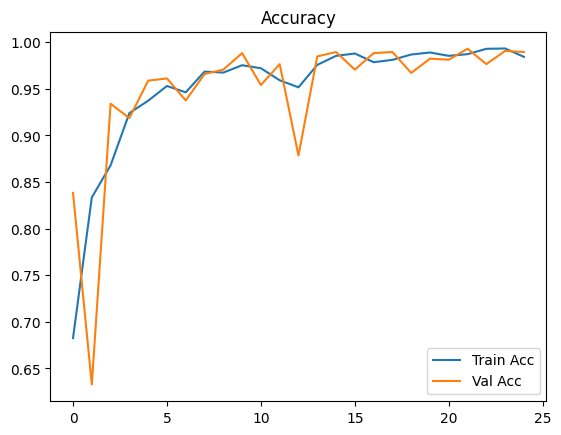

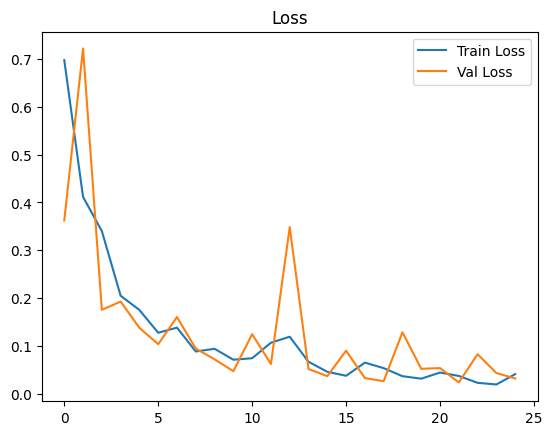

In [ ]:
# Plot training curves
plt.figure()
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

# Step 7: Save/load model

Model Architecture: The entire network definition (layers, layer connections, etc.).
Weights: The final trained weights from the last epoch (or whichever epoch you explicitly saved).
(If compiled) Training Configuration: Loss function, optimizer settings, and metrics.

In [ ]:
# Save the final model in Keras format
model.save("brain_tumor_model_final.keras")
print("Model saved as brain_tumor_model_final.keras.")

Model saved as brain_tumor_model_final.keras.


##Load model

In [99]:
model_path = "/content/brain_tumor_model_final (2).keras" #musí být jako zip
import tensorflow as tf
model = tf.keras.models.load_model(model_path)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │         131,3

 Total params: 44,540,363 (169.91 MB)

 Trainable params: 14,846,787 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 29,693,576 (113.27 MB)

In [100]:
# Load the best weights
model.load_weights("/content/brain_tumor_model_final (2).keras")

# Evaluate on validation set
val_loss, val_acc = model.evaluate(val_generator)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 386ms/step - accuracy: 0.9918 - loss: 0.0240
Validation Loss: 0.0211
Validation Accuracy: 0.9929


In [101]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 392ms/step - accuracy: 0.9936 - loss: 0.0160
Test Loss: 0.0158
Test Accuracy: 0.9942


# Confusion Matrix

27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 384ms/step
Confusion Matrix (raw counts):
[[203   2   0]
 [  1 394   0]
 [  1   1 262]]


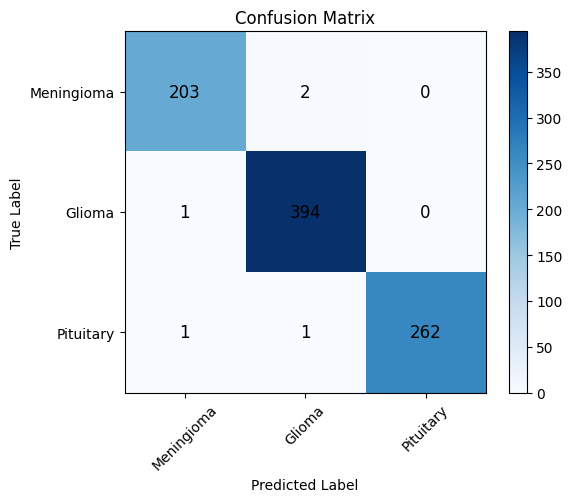

In [102]:
# 1. Get predictions
# This returns probabilities for each class
y_pred_proba = model.predict(test_generator)

# Convert probabilities to class indices
y_pred = np.argmax(y_pred_proba, axis=1)

# 2. Get true labels from the generator
# (These are the integer class indices for each image in the test set.)
y_true = test_generator.classes

# 3. Build the confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix (raw counts):")
print(cm)

# 4. Plot the confusion matrix
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

# Optional: If you have class names in a list (e.g., ["Meningioma","Glioma","Pituitary"]), use them:
class_names = ["Meningioma", "Glioma", "Pituitary"]
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]),
                 ha='center', va='center', color='black', fontsize=12)

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

In [106]:

# Example
results = pd.DataFrame({
    "Image Path": test_generator.filenames,
    "True Label": y_true,
    "Predicted Label": y_pred
})

In [109]:
misclassified = results[results["True Label"] != results["Predicted Label"]]
print(misclassified)

     Image Path  True Label  Predicted Label
53   1/2497.png           0                1
167  1/2952.png           0                1
450   2/460.png           1                0
619  3/1065.png           2                0
861   3/987.png           2                1


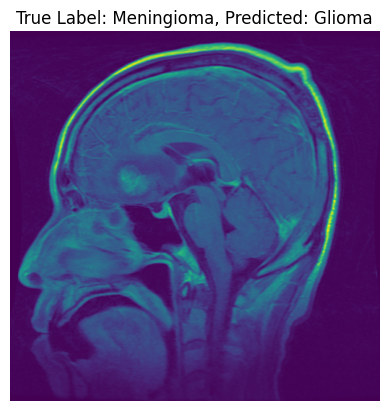

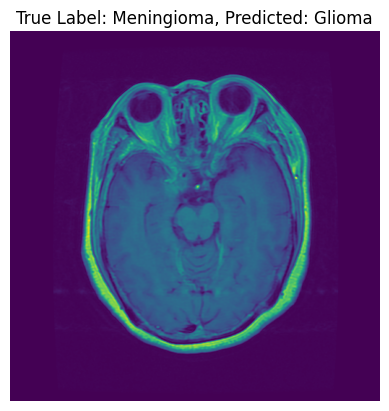

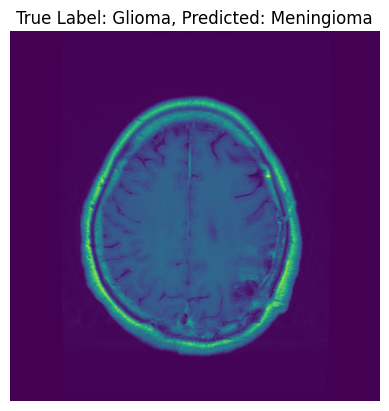

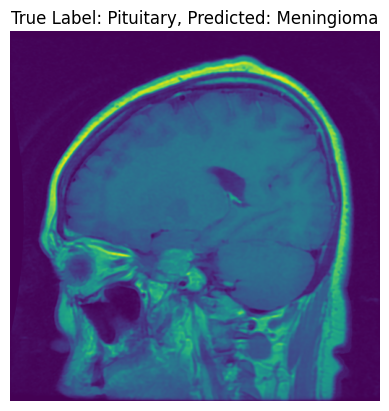

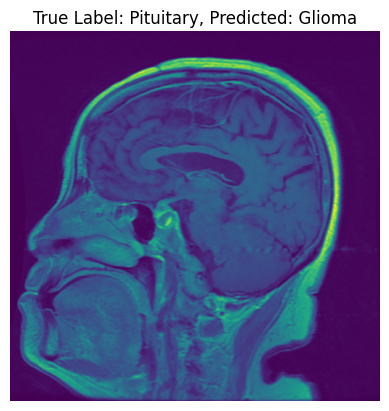

In [110]:
# Example: Display first misclassified image
for _, row in misclassified.iterrows():
    img_path = row["Image Path"]
    img = mpimg.imread(f"{dataset_path}/{img_path}")
    plt.imshow(img)
    # Adjust labels for label_map (add 1)
    true_label = str(row['True Label'] + 1)
    predicted_label = str(row['Predicted Label'] + 1)
    plt.title(f"True Label: {label_map[true_label]}, Predicted: {label_map[predicted_label]}")
    plt.axis("off")
    plt.show()

In [112]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Generates a Grad-CAM heatmap for a single preprocessed input (1,H,W,3).
    """
    grad_model = tf.keras.models.Model(
        inputs=[model.inputs],
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]  # (H, W, channels)
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]  # => (H, W, 1)
    heatmap = tf.squeeze(heatmap)                           # => (H, W)

    # Normalize to [0..1]
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def display_gradcam_for_path(
    img_path,
    model,
    last_conv_layer_name,
    preprocess_fn=None,
    class_names=None
):
    """
    Loads an image from disk at img_path,
    generates and displays the Grad-CAM overlay.
    """

    # 1) Load & resize
    original_img_bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)
    if original_img_bgr is None:
        raise ValueError(f"Could not read image at {img_path}")

    original_img_bgr = cv2.resize(original_img_bgr, (224, 224))
    original_img_rgb = cv2.cvtColor(original_img_bgr, cv2.COLOR_BGR2RGB)

    # 2) Preprocess for the model
    img_array = np.expand_dims(original_img_rgb.astype("float32"), axis=0)
    if preprocess_fn is not None:
        img_array = preprocess_fn(img_array)

    # 3) Model prediction
    preds = model.predict(img_array)
    pred_class_idx = np.argmax(preds[0])
    confidence = preds[0][pred_class_idx]

    if class_names and pred_class_idx < len(class_names):
        predicted_label = class_names[pred_class_idx]
    else:
        predicted_label = f"Class {pred_class_idx}"

    # 4) Grad-CAM heatmap
    heatmap = make_gradcam_heatmap(
        img_array=img_array,
        model=model,
        last_conv_layer_name=last_conv_layer_name,
        pred_index=pred_class_idx
    )

    # Convert [0..1] -> [0..255], colorize (H,W,3), then upscale to (224,224)
    heatmap_uint8 = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    heatmap_color = cv2.resize(heatmap_color, (224, 224), interpolation=cv2.INTER_CUBIC)

    # 5) Overlay
    original_img_rgb_uint8 = original_img_rgb.astype("uint8")
    heatmap_color_uint8    = heatmap_color.astype("uint8")

    superimposed_img = cv2.addWeighted(
        original_img_rgb_uint8, 0.6,
        heatmap_color_uint8,     0.4,
        0
    )

    # 6) Display
    plt.figure()
    plt.imshow(original_img_rgb_uint8)
    plt.title("Original (224x224)")
    plt.axis("off")
    plt.show()

    plt.figure()
    plt.imshow(superimposed_img)
    plt.title(f"Grad-CAM: {predicted_label} (Conf: {confidence:.2f})")
    plt.axis("off")
    plt.show()


Misclassified Sample #53:
  Path: brain_tumor_split/test/1/2497.png
  True Label: Meningioma
  Model Predicted: Glioma
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_2']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


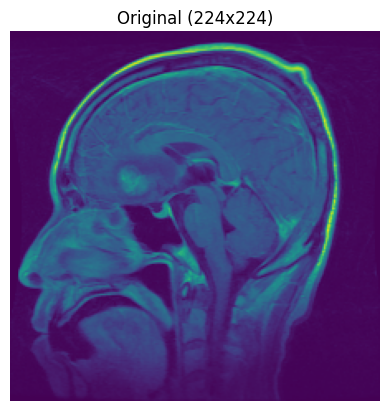

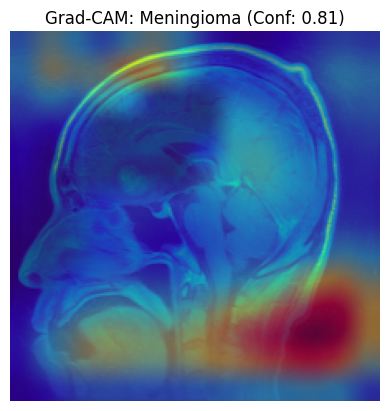


Misclassified Sample #167:
  Path: brain_tumor_split/test/1/2952.png
  True Label: Meningioma
  Model Predicted: Glioma
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


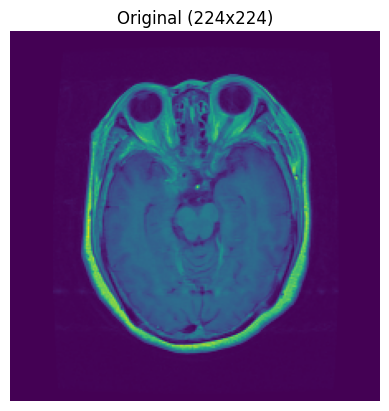

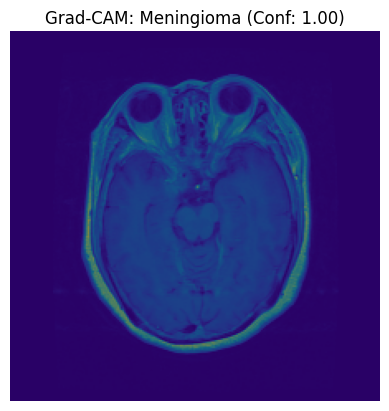


Misclassified Sample #450:
  Path: brain_tumor_split/test/2/460.png
  True Label: Glioma
  Model Predicted: Meningioma
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


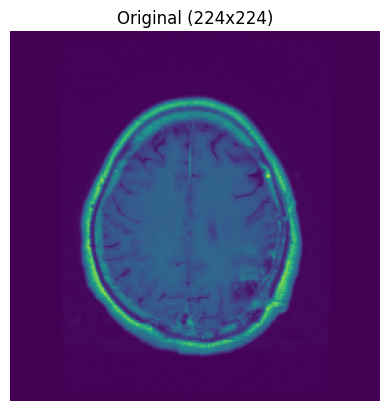

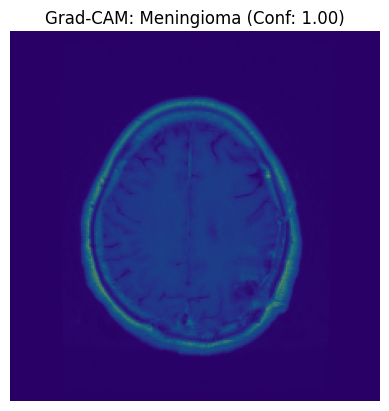


Misclassified Sample #619:
  Path: brain_tumor_split/test/3/1065.png
  True Label: Pituitary
  Model Predicted: Meningioma
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


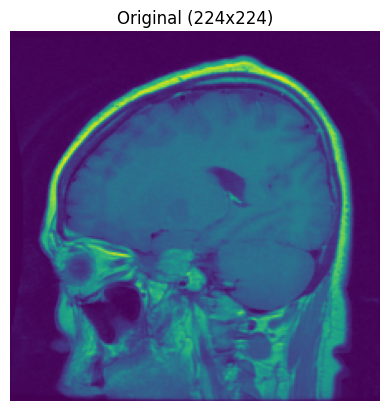

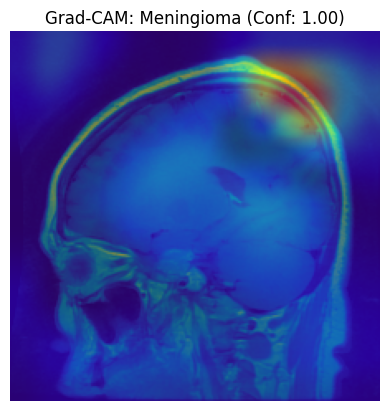


Misclassified Sample #861:
  Path: brain_tumor_split/test/3/987.png
  True Label: Pituitary
  Model Predicted: Glioma
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


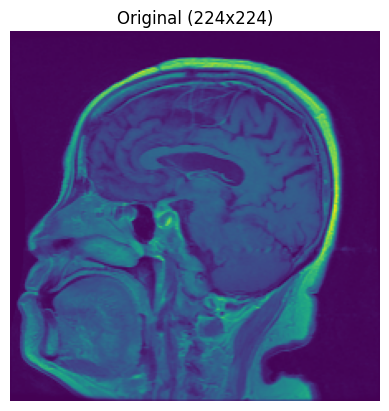

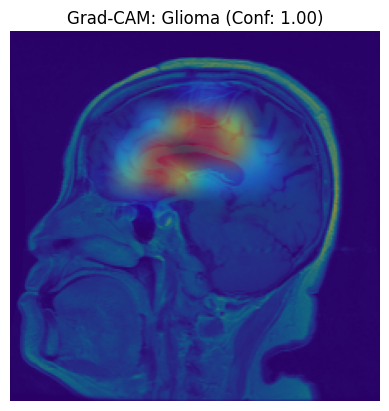

In [113]:
import os

# Example usage:
last_conv_layer_name = "block5_conv3"      # For VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

# Show Grad-CAM for each misclassified example
for i, row in misclassified.iterrows():
    # Build the absolute path to the test image
    # (Note: test_generator.directory is the root directory for your test data)
    img_path = os.path.join(test_generator.directory, row["Image Path"])
    true_label = class_names[row["True Label"]]
    pred_label = class_names[row["Predicted Label"]]

    print(f"\nMisclassified Sample #{i}:")
    print(f"  Path: {img_path}")
    print(f"  True Label: {true_label}")
    print(f"  Model Predicted: {pred_label}")

    # Display Grad-CAM
    display_gradcam_for_path(
        img_path=img_path,
        model=model,
        last_conv_layer_name=last_conv_layer_name,
        preprocess_fn=preprocess_input,
        class_names=class_names
    )

    # If you only want a few examples, you can break here:
    # if i > 10:
    #     break